In [22]:
import pandas as pd
import numpy as np
import joblib

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification Models
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier


# Regression Models
from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from xgboost import XGBRegressor

In [23]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

In [24]:
df = pd.read_csv("cleaned.csv")

df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Security,Amenities,Facing,Owner_Type,Availability_Status,Future_Price_5Y,Transport_Score,Amenities_Count,Price_Value_Score,Good_Investment
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,10332.489451,1990,...,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,719.618119,2,5,0,0
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,8270.727580,2008,...,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,287.283026,0,5,1,1
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,5046.403075,1997,...,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,270.047807,0,4,1,0
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,10955.490697,1991,...,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,441.224528,2,5,0,0
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,3792.245490,2002,...,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,268.740105,0,5,1,1


In [25]:
label_encoders = {}

categorical_columns = df.select_dtypes(
    include="object"
).columns


for col in categorical_columns:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    label_encoders[col] = le


df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Security,Amenities,Facing,Owner_Type,Availability_Status,Future_Price_5Y,Transport_Score,Amenities_Count,Price_Value_Score,Good_Investment
0,1,15,6,483,0,1,4740,489.76,10332.489451,1990,...,0,238,3,2,0,719.618119,2,5,0,0
1,2,11,33,434,1,3,2364,195.52,8270.727580,2008,...,1,211,1,1,1,287.283026,0,5,1,1
2,3,13,25,75,0,2,3642,183.79,5046.403075,1997,...,0,63,2,0,0,270.047807,0,4,1,0
3,4,14,21,326,1,2,2741,300.29,10955.490697,1991,...,1,206,1,1,0,441.224528,2,5,0,0
4,5,14,19,407,2,4,4823,182.90,3792.245490,2002,...,1,222,0,1,0,268.740105,0,5,1,1


classification

In [26]:
# =========================================================
# CLASSIFICATION TARGET
# =========================================================

X_class = df.drop(
    [
        "Good_Investment",
        "Future_Price_5Y"
    ],
    axis=1
)


# Remove ID column
if "ID" in X_class.columns:

    X_class = X_class.drop(
        "ID",
        axis=1
    )


# Remove leakage columns
remove_cols = [

    "Investment_Score",

    "Price_Value_Score"
]

for col in remove_cols:

    if col in X_class.columns:

        X_class = X_class.drop(
            col,
            axis=1
        )


y_class = df["Good_Investment"]


# Save feature columns
feature_columns = X_class.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)


# =========================================================
# SCALING
# =========================================================

scaler = StandardScaler()

X_class_scaled = scaler.fit_transform(
    X_class
)


In [27]:
# TRAIN TEST SPLIT


X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
X_class_scaled,
y_class,
test_size=0.2,
random_state=42,
stratify=y_class
)

# SMOTE BALANCING

smote = SMOTE(
random_state=42
)

X_train_c, y_train_c = smote.fit_resample(
X_train_c,
y_train_c
)

# Check balanced training classes

print(
y_train_c.value_counts()
)


Good_Investment
0    139930
1    139930
Name: count, dtype: int64


In [28]:
#classification
classification_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "XGBoost": XGBClassifier(
        eval_metric='logloss'
    )
}

In [29]:
#evaluate

classification_results = []

best_classification_model = None

best_f1 = 0


mlflow.set_experiment(
    "Real_Estate_Classification"
)

for name, model in classification_models.items():

    with mlflow.start_run(run_name=name):

        print(f"\nTraining {name}...\n")

        model.fit(X_train_c, y_train_c)

        y_pred = model.predict(X_test_c)

        accuracy = accuracy_score(y_test_c, y_pred)

        precision = precision_score(y_test_c, y_pred)

        recall = recall_score(y_test_c, y_pred)

        f1 = f1_score(y_test_c, y_pred)

        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")

        mlflow.log_param("model_name", name)

        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        classification_results.append({

    "Model": name,

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1 Score": f1
})

        mlflow.sklearn.log_model(
            model,
            name
        )

        if f1 > best_f1:

            best_f1 = f1

            best_classification_model = model


Training Logistic Regression...



2026/06/09 16:09:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy : 0.8980
Precision: 0.7889
Recall   : 0.9017
F1 Score : 0.8415


2026/06/09 16:09:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Training Decision Tree...



...

2026/06/09 16:14:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 16:14:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy : 0.9978
Precision: 0.9953
Recall   : 0.9972
F1 Score : 0.9963

Training XGBoost...



2026/06/09 16:14:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Accuracy : 0.9988
Precision: 0.9977
Recall   : 0.9983
F1 Score : 0.9980


2026/06/09 16:14:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [30]:
classification_df = pd.DataFrame(
    classification_results
)

classification_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.99926,0.998669,0.998868,0.998768
4,XGBoost,0.99882,0.997737,0.998335,0.998036
3,Gradient Boosting,0.99776,0.995348,0.997203,0.996275
2,Random Forest,0.99742,0.994947,0.996471,0.995708
0,Logistic Regression,0.89798,0.788873,0.901651,0.841500


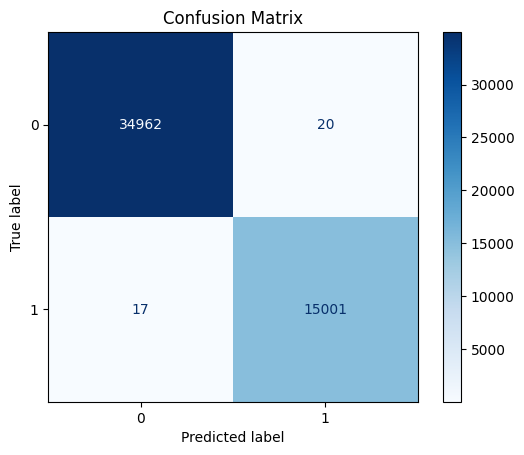

In [31]:
#confusion matrix
best_pred = best_classification_model.predict(
    X_test_c
)

cm = confusion_matrix(
    y_test_c,
    best_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

regression


In [32]:
# =========================================================
# REGRESSION TARGET
# =========================================================

X_reg = df.drop(
    [
        "Future_Price_5Y",
        "Good_Investment"
    ],
    axis=1
)


# Remove ID column
if "ID" in X_reg.columns:

    X_reg = X_reg.drop(
        "ID",
        axis=1
    )


# Remove leakage columns
remove_cols = [

    "Investment_Score",

    "Price_Value_Score"
]

for col in remove_cols:

    if col in X_reg.columns:

        X_reg = X_reg.drop(
            col,
            axis=1
        )


y_reg = df["Future_Price_5Y"]


# =========================================================
# SCALING
# =========================================================

X_reg_scaled = scaler.fit_transform(
    X_reg
)


In [33]:
#train-test

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg_scaled,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [34]:
#regression

regression_models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree Regressor": DecisionTreeRegressor(),

    "Random Forest Regressor": RandomForestRegressor(),

    "Gradient Boosting Regressor": GradientBoostingRegressor(),

    "XGBoost Regressor": XGBRegressor()
}

In [35]:
#evaluate

regression_results = []

best_regression_model = None

best_r2 = 0


mlflow.set_experiment(
    "Real_Estate_Regression"
)

for name, model in regression_models.items():

    with mlflow.start_run(run_name=name):

        print(f"\nTraining {name}...\n")

        model.fit(X_train_r, y_train_r)

        y_pred = model.predict(X_test_r)

        mae = mean_absolute_error(
            y_test_r,
            y_pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test_r,
                y_pred
            )
        )

        r2 = r2_score(
            y_test_r,
            y_pred
        )

        print(f"MAE  : {mae:.4f}")
        print(f"RMSE : {rmse:.4f}")
        print(f"R2   : {r2:.4f}")

        mlflow.log_param("model_name", name)

        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        regression_results.append({

    "Model": name,

    "MAE": mae,

    "RMSE": rmse,

    "R2 Score": r2
})

        mlflow.sklearn.log_model(
            model,
            name
        )

        if r2 > best_r2:

            best_r2 = r2

            best_regression_model = model


Training Linear Regression...



2026/06/09 16:14:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 16:14:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MAE  : 0.0000
RMSE : 0.0000
R2   : 1.0000

Training Decision Tree Regressor...



2026/06/09 16:15:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 16:15:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MAE  : 0.0029
RMSE : 0.0070
R2   : 1.0000

Training Random Forest Regressor...



...

2026/06/09 16:20:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 16:20:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MAE  : 1.0751
RMSE : 1.4211
R2   : 1.0000

Training XGBoost Regressor...



2026/06/09 16:20:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MAE  : 0.7053
RMSE : 0.8185
R2   : 1.0000


2026/06/09 16:20:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [36]:
regression_df = pd.DataFrame(
    regression_results
)

regression_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.933060e-13,4.881040e-13,1.000000
2,Random Forest Regressor,2.107654e-03,3.319199e-03,1.000000
1,Decision Tree Regressor,2.866071e-03,7.008864e-03,1.000000
4,XGBoost Regressor,7.052545e-01,8.185114e-01,0.999984
3,Gradient Boosting Regressor,1.075110e+00,1.421141e+00,0.999953


In [37]:
# Feature Importance

# Create feature importance safely

if hasattr(
    best_classification_model,
    "feature_importances_"
):

    importance = (
        best_classification_model
        .feature_importances_
    )

else:

    importance = np.abs(
        best_classification_model.coef_[0]
    )


# Create dataframe

importance_df = pd.DataFrame({

    "Feature": X_class.columns,

    "Importance": importance
})


# Remove unwanted columns

importance_df = importance_df[
    ~importance_df["Feature"].isin(
        [
            "Investment_Score",
            "ID"
        ]
    )
]


# Sort values

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)


# Show top features

importance_df.head(10)

,Feature,Importance
7,Price_per_SqFt,0.551720
4,BHK,0.442515
1,City,0.003203
0,State,0.002139
2,Locality,0.000069
19,Facing,0.000063
18,Amenities,0.000049
11,Total_Floors,0.000048
14,Nearby_Hospitals,0.000037
5,Size_in_SqFt,0.000027


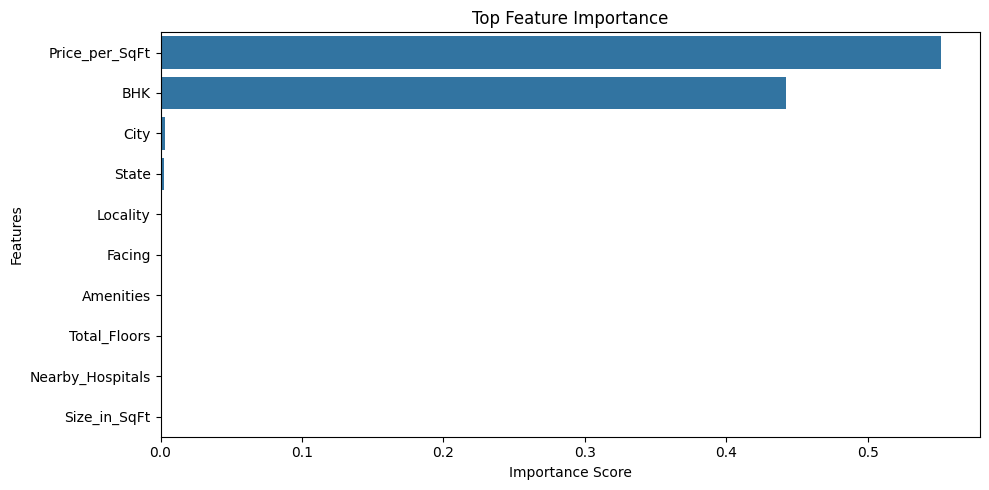

In [38]:
# Plot Feature Importance

top_features = importance_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_features["Importance"],
    y=top_features["Feature"]
)

plt.title("Top Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.tight_layout()

plt.show()

In [39]:
best_classification_model = classification_models[
    "Gradient Boosting"
]

best_regression_model = regression_models[
    "XGBoost Regressor"
]

In [40]:
joblib.dump(
    best_classification_model,
    "best_classification_model.pkl"
)

joblib.dump(
    best_regression_model,
    "best_regression_model.pkl"
)

joblib.dump(
    label_encoders,
    "label_encoders.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


In [41]:
mlflow.set_experiment("Test_Experiment")

with mlflow.start_run():

    mlflow.log_param("test_param", 123)

    mlflow.log_metric("test_metric", 0.95)

print("MLflow Working")

MLflow Working
